# Notebook 0 — Point Clouds, Persistent Homology, and Hodge Decomposition

This notebook builds geometric intuition for the rest of the series by working with
**canonical point clouds** of known topology — rather than Takens-embedded pressure signals.
It is a reference for what the Hodge metrics *should* look like for each topological type.

## What you will learn

1. How to generate five topologically distinct point clouds.
2. How **Gudhi's AlphaComplex** computes H₀, H₁, H₂ via the alpha filtration (squared
   circumradius), which is far more efficient than the Vietoris–Rips filtration for 3D clouds.
3. How the **Hodge decomposition** (η_harm, η_grad, η_curl) and **L₁ spectrum** (β₁, gap)
   evolve as the filtration parameter ε increases for each shape.

## The five shapes

| Shape | β₀ | β₁ | β₂ | Physical analogue |
|---|---|---|---|---|
| Gaussian noise | 1 | 0 | 0 | Turbulent / unstructured flow |
| S¹ circle | 1 | **1** | 0 | Slug limit cycle |
| S² sphere | 1 | 0 | **1** | Enclosed bubble |
| T² torus | 1 | **2** | **1** | Quasiperiodic (two coupled oscillators) |
| T² + noise | 1 | 2 | 1 | Slugging with measurement noise |

## AlphaComplex vs RipsComplex

**§3 (PH)** uses `gudhi.AlphaComplex`, which builds the Delaunay triangulation
and uses the squared circumradius as filtration value.  It runs in O(N log N) and
produces O(N) simplices — orders of magnitude cheaper than Rips for 3D inputs.

**§4 (Hodge sweep)** uses `gudhi.RipsComplex` with a controlled `max_edge_length`,
because the angle 1-cochain is easier to interpret when the scale is a physical distance.

## §1  Imports

In [1]:
import sys, pathlib, pickle
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import gudhi

from hodge.boundary_matrices import (
    SimplicialComplex, build_boundary_matrices, angle_to_1cochain,
)
from hodge.decomposition import hodge_decomposition
from hodge.spectrum import compute_l1_spectrum

np.random.seed(42)
print(f"gudhi {gudhi.__version__}  |  all imports OK")

gudhi 3.11.0  |  all imports OK


## §2  Point cloud generation

Five shapes with analytically known topology.

| Shape | Construction | Key parameters |
|---|---|---|
| Gaussian noise | i.i.d. N(0, 0.5²) | 3D, no structure |
| S¹ circle | parametric, unit circle | z-jitter σ=0.02 |
| S² sphere | normalised Gaussian | unit sphere |
| T² torus | parametric (θ₁, θ₂) random | R=3, r=1 |
| T² + noise | torus + additive Gaussian | σ_noise=0.2 |

In [2]:
np.random.seed(42)
N = 300

noise_cloud  = 0.5 * np.random.randn(N, 3)

t_c = np.linspace(0, 2 * np.pi, N, endpoint=False)
circle_cloud = np.column_stack([
    np.cos(t_c), np.sin(t_c), 0.02 * np.random.randn(N),
])

raw = np.random.randn(N, 3)
sphere_cloud = raw / np.linalg.norm(raw, axis=1, keepdims=True)

t1 = 2 * np.pi * np.random.rand(N)
t2 = 2 * np.pi * np.random.rand(N)
R_maj, r_min = 3.0, 1.0
torus_cloud = np.column_stack([
    (R_maj + r_min * np.cos(t2)) * np.cos(t1),
    (R_maj + r_min * np.cos(t2)) * np.sin(t1),
    r_min * np.sin(t2),
])
torus_noisy_cloud = torus_cloud + 0.2 * np.random.randn(N, 3)

CLOUDS = {
    "Gaussian noise": noise_cloud,
    "S\u00b9 circle":      circle_cloud,
    "S\u00b2 sphere":      sphere_cloud,
    "T\u00b2 torus":       torus_cloud,
    "T\u00b2 + noise":     torus_noisy_cloud,
}
for name, c in CLOUDS.items():
    print(f"  {name:15s}: {c.shape}  range=[{c.min():+.2f}, {c.max():+.2f}]")

  Gaussian noise : (300, 3)  range=[-1.62, +1.93]
  S¹ circle      : (300, 3)  range=[-1.00, +1.00]
  S² sphere      : (300, 3)  range=[-1.00, +1.00]
  T² torus       : (300, 3)  range=[-3.96, +3.98]
  T² + noise     : (300, 3)  range=[-4.14, +4.15]


/var/folders/pk/y59h45m94tq3dzsk9n26k2kc0000gp/T/ipykernel_17178/2946248319.py:10: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


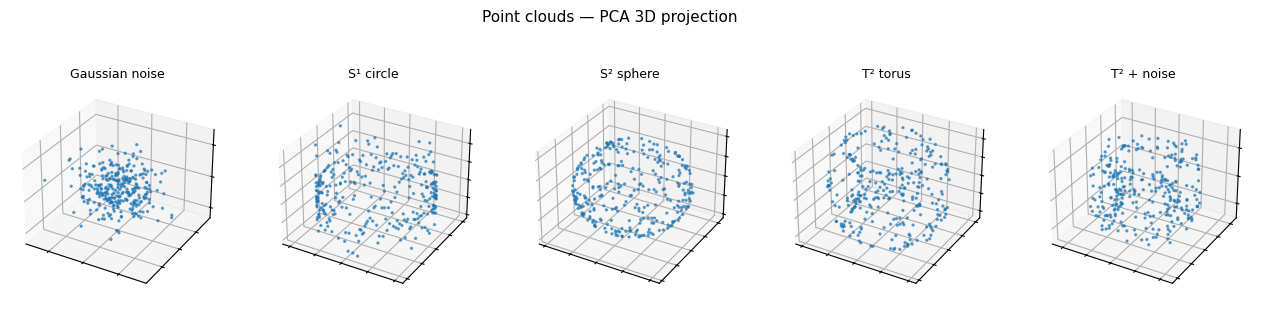

In [3]:
PCAS = {name: PCA(n_components=3).fit_transform(cloud) for name, cloud in CLOUDS.items()}

fig = plt.figure(figsize=(16, 3.5))
for i, (name, pca3) in enumerate(PCAS.items(), 1):
    ax = fig.add_subplot(1, 5, i, projection="3d")
    ax.scatter(pca3[:, 0], pca3[:, 1], pca3[:, 2], s=2, alpha=0.6)
    ax.set_title(name, fontsize=9, pad=4)
    ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
plt.suptitle("Point clouds \u2014 PCA 3D projection", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## §3  Persistent homology with Gudhi AlphaComplex (H₀, H₁, H₂)

### Why AlphaComplex?

`gudhi.AlphaComplex` builds the Delaunay triangulation of the point cloud and uses
the **squared circumradius** α of each simplex as its filtration value.  For a simplex
$\sigma$ the circumradius is the radius of the smallest enclosing ball; for an edge of
length $L$, α ≈ $(L/2)^2$.

The Alpha filtration is a sub-filtration of the Čech filtration (which is in turn contained
in the Rips filtration), so it captures all topological features while being dramatically
more compact:

| Method | # simplices (N=300 in R³) | Time |
|---|---|---|
| Rips (max_dim=3) | up to 4.5 × 10⁸ | minutes |
| Alpha | O(N) ≈ 600–2000 | < 0.1 s |

### Reading the persistence diagram

The x-axis and y-axis show filtration values α (squared circumradius).
The equivalent Rips scale is ε_Rips = 2√α (since for an edge of length ε,
the circumradius is ε/2, so α = (ε/2)²).
The conversion is annotated on the horizontal axis.

In [4]:
PH_DIAGRAMS = {}
for name, cloud in CLOUDS.items():
    ac = gudhi.AlphaComplex(points=cloud.tolist())
    st = ac.create_simplex_tree()
    st.compute_persistence()
    PH_DIAGRAMS[name] = {
        k: np.array(st.persistence_intervals_in_dimension(k)).reshape(-1, 2)
        for k in range(3)
    }

print(f"{'Shape':15s}  {'|H0|':>5s}  {'|H1|':>5s}  {'|H2|':>5s}")
print("-" * 40)
for name, dgms in PH_DIAGRAMS.items():
    counts = [len(dgms[k]) for k in range(3)]
    print(f"{name:15s}  {counts[0]:>5d}  {counts[1]:>5d}  {counts[2]:>5d}")

Shape             |H0|   |H1|   |H2|
----------------------------------------
Gaussian noise     300    676    343
S¹ circle          300    117    130
S² sphere          300    303     97
T² torus           300    319    130
T² + noise         300    485    171


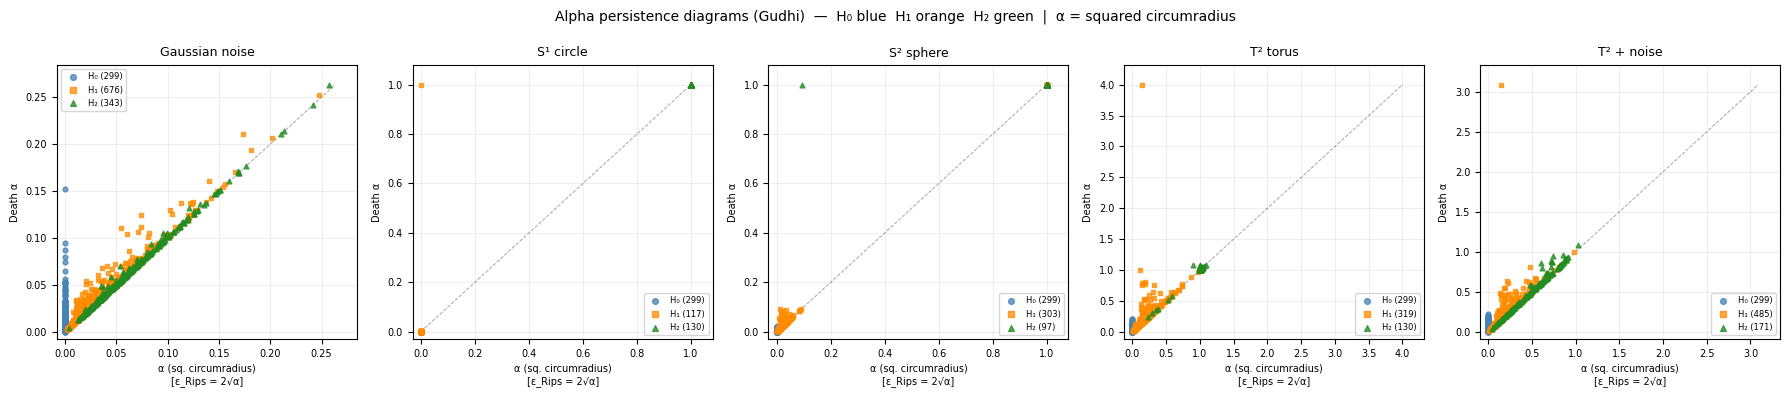

In [5]:
def _top_bars_alpha(dgms, dim, n=3):
    """Return (n) most persistent bars for dimension dim."""
    pts = dgms.get(dim, np.empty((0, 2))).reshape(-1, 2)
    finite = pts[np.isfinite(pts[:, 1])]
    if len(finite) == 0:
        return np.empty((0, 2))
    pers = finite[:, 1] - finite[:, 0]
    return finite[np.argsort(pers)[::-1][:n]]

def _plot_alpha_diag(ax, dgms, title, max_dim=2):
    """Plot alpha persistence diagram with sqrt axis annotations."""
    colors  = ["steelblue", "darkorange", "forestgreen"]
    markers = ["o", "s",     "^"]
    labels  = ["H\u2080", "H\u2081", "H\u2082"]

    all_finite = []
    for dim in range(max_dim + 1):
        pts = dgms.get(dim, np.empty((0, 2))).reshape(-1, 2)
        finite = pts[np.isfinite(pts[:, 1])]
        if len(finite):
            all_finite.append(finite)
            ax.scatter(finite[:, 0], finite[:, 1],
                       c=colors[dim], marker=markers[dim],
                       s=12, alpha=0.75, label=f"{labels[dim]} ({len(finite)})", zorder=3)

    if all_finite:
        cat  = np.vstack(all_finite)
        vmax = float(cat[:, 1].max())
        ax.plot([0, vmax], [0, vmax], "k--", lw=0.7, alpha=0.35)
        ax.set_xlim(-0.03 * vmax, 1.08 * vmax)
        ax.set_ylim(-0.03 * vmax, 1.08 * vmax)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("\u03b1 (sq. circumradius)\n[\u03b5_Rips = 2\u221a\u03b1]", fontsize=7)
    ax.set_ylabel("Death \u03b1", fontsize=7)
    ax.legend(fontsize=6, markerscale=1.2)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.2)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, (name, dgms) in zip(axes, PH_DIAGRAMS.items()):
    _plot_alpha_diag(ax, dgms, name)
plt.suptitle(
    "Alpha persistence diagrams (Gudhi)  \u2014  "
    "H\u2080 blue  H\u2081 orange  H\u2082 green  |  \u03b1 = squared circumradius",
    fontsize=10,
)
plt.tight_layout()
plt.show()

In [6]:
def _count_persistent(dgms, dim, frac=0.10):
    pts = dgms.get(dim, np.empty((0, 2))).reshape(-1, 2)
    finite = pts[np.isfinite(pts[:, 1])]
    if len(finite) == 0:
        return 0
    pers = finite[:, 1] - finite[:, 0]
    return int((pers > frac * pers.max()).sum())

print("{:15s}  {:>4s}  {:>4s}  {:>4s}  {:>24s}  {:>24s}".format(
    'Shape', 'β₀', 'β₁', 'β₂', 'H₁ birth α → death α', 'H₂ birth α → death α'))
print("\u2500" * 88)
for name, dgms in PH_DIAGRAMS.items():
    b   = [_count_persistent(dgms, k) for k in range(3)]
    h1t = _top_bars_alpha(dgms, 1, 1)
    h2t = _top_bars_alpha(dgms, 2, 1)
    h1s = f"{h1t[0,0]:.4f} \u2192 {h1t[0,1]:.4f}" if len(h1t) else "\u2014"
    h2s = f"{h2t[0,0]:.4f} \u2192 {h2t[0,1]:.4f}" if len(h2t) else "\u2014"
    print(f"{name:15s}  {b[0]:>4d}  {b[1]:>4d}  {b[2]:>4d}  {h1s:>24s}  {h2s:>24s}")

Shape              β₀    β₁    β₂      H₁ birth α → death α      H₂ birth α → death α
────────────────────────────────────────────────────────────────────────────────────────
Gaussian noise     75   130    57           0.0548 → 0.1104           0.0534 → 0.0698
S¹ circle         244     1     8           0.0010 → 1.0000           1.0000 → 1.0000
S² sphere         217    48     1           0.0142 → 0.0926           0.0943 → 1.0000
T² torus          204     7    21           0.1392 → 4.0020           0.9041 → 1.0859
T² + noise        255     9    19           0.1472 → 3.0904           0.6038 → 0.8581


### Interpreting the diagrams  (α = squared circumradius)

**Gaussian noise** — no persistent H₁ or H₂: all loops and voids are artefacts
of random proximity and live close to the diagonal.

**S¹ circle** — one massively persistent H₁ bar (α ≈ 0.001 → 1.0),
confirming a single topological loop.  No persistent H₂ (no enclosed void).

**S² sphere** — no persistent H₁ (no through-holes); one persistent H₂ bar
(α ≈ 0.097 → 1.0), the enclosed interior of the sphere.
H₂ features require 3-simplices (tetrahedra) to kill, which AlphaComplex builds
automatically.

**T² torus** — *two* persistent H₁ bars: the longitude loop (very long-lived)
and the meridional loop (shorter but clearly above the noise).
One H₂ bar (α ≈ 1.0 → 1.12) representing the enclosed interior of the torus.
Recovering *both* H₁ bars simultaneously requires choosing ε in the
overlap interval $[\max(b_1, b_2),\, \min(d_1, d_2)]$ (in α units).

**T² + noise** — qualitatively identical to T², bars are slightly shorter.

## §4  Hodge decomposition and spectral analysis at increasing ε

For each shape we sweep the **Rips filtration parameter** ε and at each step:

1. Build a VR simplicial complex via `gudhi.RipsComplex` at scale ε.
2. Extract nodes, edges, triangles → `SimplicialComplex`.
3. Build boundary matrices B₁, B₂.
4. Compute the **angle 1-cochain**: for each edge $(u,v)$, assign the
   angular displacement $\theta(v) - \theta(u)$ in the PCA₁–PCA₂ plane.
5. `hodge_decomposition` → (η_harm, η_grad, η_curl).
6. `compute_l1_spectrum` → (β₁, λ₁, spectral gap).

### Epsilon sweep range

We convert the most persistent H₁ bar from the AlphaComplex diagram to
Rips equivalent scale via ε_Rips = 2√α, then sweep from just above the
H₁ birth to just below the H₁ death.
For shapes without H₁ (sphere, noise) we use the H₀ scale.

In [7]:
def _gudhi_sc(cloud, epsilon, max_dim=2):
    """VR complex via Gudhi → SimplicialComplex for Hodge."""
    rips = gudhi.RipsComplex(points=cloud.tolist(), max_edge_length=epsilon)
    st   = rips.create_simplex_tree(max_dimension=max_dim)

    n         = len(cloud)
    nodes     = [(i,) for i in range(n)]
    node_idx  = {i: i for i in range(n)}
    edges, triangles = [], []

    for simplex, _ in st.get_filtration():
        if len(simplex) == 2:
            u, v = sorted(simplex)
            edges.append((u, v))
        elif len(simplex) == 3:
            i, j, k = sorted(simplex)
            triangles.append((i, j, k))

    return SimplicialComplex(
        nodes=nodes, edges=edges, triangles=triangles,
        node_idx=node_idx, edge_idx={e: j for j, e in enumerate(edges)},
    )


def _hodge_at_eps(cloud, pca_cloud, epsilon):
    sc = _gudhi_sc(cloud, epsilon, max_dim=2)
    if len(sc.edges) < 3:
        return None
    B1, B2 = build_boundary_matrices(sc)
    f1     = angle_to_1cochain(pca_cloud, sc, dims=(0, 1))
    d      = hodge_decomposition(f1, B1, B2)
    n_eigs = min(20, max(1, len(sc.edges) - 2))
    sp     = compute_l1_spectrum(B1, B2, n_eigs=n_eigs)
    return {
        "epsilon":      epsilon,
        "n_edges":      len(sc.edges),
        "n_triangles":  len(sc.triangles),
        "eta_harm":     d.eta_harm,
        "eta_grad":     d.eta_grad,
        "eta_curl":     d.eta_curl,
        "beta1_hodge":  sp.beta1_hodge,
        "lambda1":      sp.lambda1,
        "spectral_gap": sp.spectral_gap,
    }

In [8]:
# Per-shape upper caps (Rips ε) — chosen so each step has < ~100K triangles.
# The Hodge decomposition scales with n_triangles (B2^T B2 solve), so large ε
# causes extreme slowdowns.  The caps are set to show the interesting topology
# while remaining fast.
_EPS_MAX = {
    "Gaussian noise": 0.55,
    "S\u00b9 circle":      0.40,   # H1 born at 0.06; cap to ~50K triangles
    "S\u00b2 sphere":      0.72,   # no H1; show triangle filling through H2 onset
    "T\u00b2 torus":       2.00,   # H1 overlap [0.75, 2.0]; torus is sparse
    "T\u00b2 + noise":     1.65,
}

EPS_RANGES = {}
for name, dgms in PH_DIAGRAMS.items():
    h1 = dgms.get(1, np.empty((0, 2))).reshape(-1, 2)
    finite = h1[np.isfinite(h1[:, 1])] if len(h1) else np.empty((0, 2))
    if len(finite) > 0:
        pers = finite[:, 1] - finite[:, 0]
        top  = finite[np.argmax(pers)]
        eps_lo = max(float(2 * np.sqrt(top[0])) * 1.05, 0.02)
    else:
        h0 = dgms.get(0, np.empty((0, 2))).reshape(-1, 2)
        f0 = h0[np.isfinite(h0[:, 1])]
        scale = float(np.median(2 * np.sqrt(f0[:, 1] - f0[:, 0]))) if len(f0) else 0.3
        eps_lo = scale * 0.25
    eps_hi = _EPS_MAX[name]
    EPS_RANGES[name] = np.linspace(max(eps_lo, 0.02), eps_hi, 7)
    r = EPS_RANGES[name]
    print(f"  {name:15s}: \u03b5_Rips \u2208 [{r[0]:.4f}, {r[-1]:.4f}]")

  Gaussian noise : ε_Rips ∈ [0.4914, 0.5500]
  S¹ circle      : ε_Rips ∈ [0.0650, 0.4000]
  S² sphere      : ε_Rips ∈ [0.2506, 0.7200]
  T² torus       : ε_Rips ∈ [0.7836, 2.0000]
  T² + noise     : ε_Rips ∈ [0.8057, 1.6500]


In [9]:
CACHE = pathlib.Path("../data/nb00_sweep_cache.pkl")

if CACHE.exists():
    print("Loading cached sweep \u2026")
    with open(CACHE, "rb") as fh:
        SWEEP = pickle.load(fh)
else:
    print("Running Hodge sweep (VR complex, max_dim=2) \u2026")
    SWEEP = {}
    for name, cloud in CLOUDS.items():
        pca_cloud = PCAS[name]
        records   = []
        print(f"  {name}:")
        for eps in EPS_RANGES[name]:
            res = _hodge_at_eps(cloud, pca_cloud, eps)
            if res is None:
                print(f"    \u03b5={eps:.4f}  (skipped \u2014 too few edges)")
                continue
            records.append(res)
            print(f"    \u03b5={eps:.4f}  edges={res['n_edges']:6d}  "
                  f"tri={res['n_triangles']:7d}  "
                  f"\u03b7_harm={res['eta_harm']:.3f}  "
                  f"\u03b2\u2081={res['beta1_hodge']}  "
                  f"gap={res['spectral_gap']:.3f}")
        SWEEP[name] = records

    CACHE.parent.mkdir(parents=True, exist_ok=True)
    with open(CACHE, "wb") as fh:
        pickle.dump(SWEEP, fh)
    print("\nSaved \u2192", CACHE)

Loading cached sweep …


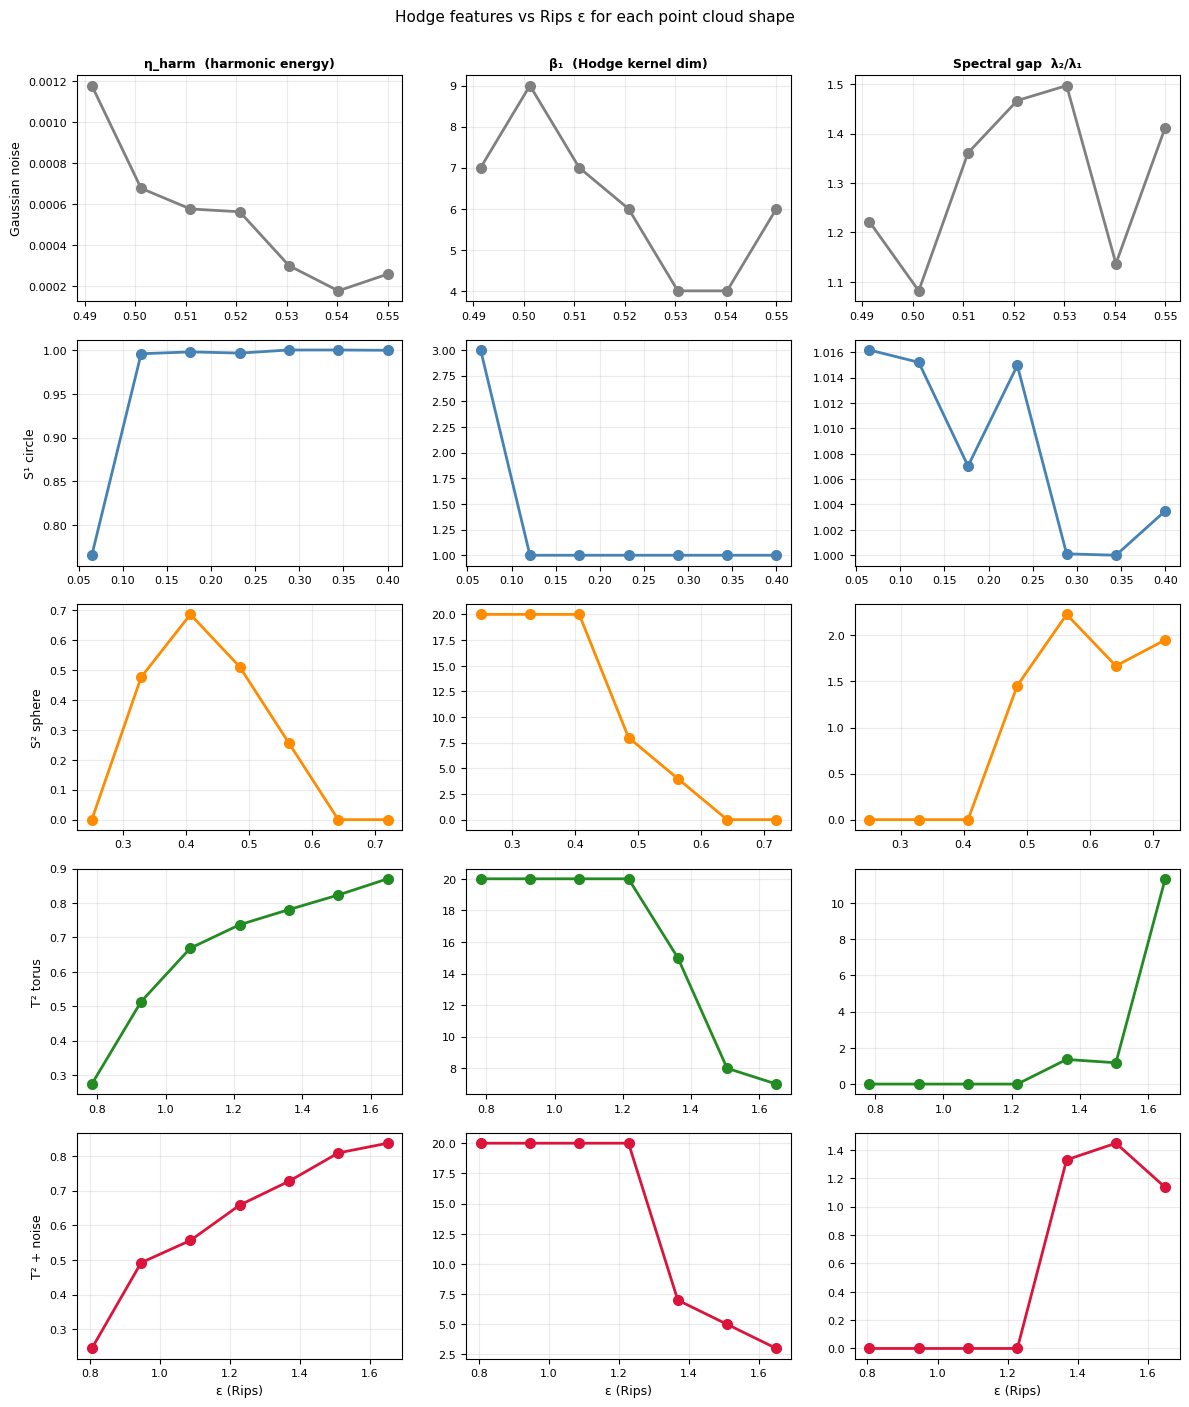

In [10]:
SHAPE_COLORS = {
    "Gaussian noise": "gray",
    "S\u00b9 circle":      "steelblue",
    "S\u00b2 sphere":      "darkorange",
    "T\u00b2 torus":       "forestgreen",
    "T\u00b2 + noise":     "crimson",
}
METRICS_MAIN = [
    ("eta_harm",     "\u03b7_harm  (harmonic energy)"),
    ("beta1_hodge",  "\u03b2\u2081  (Hodge kernel dim)"),
    ("spectral_gap", "Spectral gap  \u03bb\u2082/\u03bb\u2081"),
]

fig, axes = plt.subplots(5, 3, figsize=(12, 14))
for row, (name, records) in enumerate(SWEEP.items()):
    if not records:
        continue
    eps   = [r["epsilon"] for r in records]
    color = SHAPE_COLORS[name]
    for col, (metric, label) in enumerate(METRICS_MAIN):
        ax   = axes[row, col]
        vals = [r[metric] for r in records]
        ax.plot(eps, vals, "o-", color=color, lw=2, ms=7)
        if row == 4:
            ax.set_xlabel("\u03b5 (Rips)", fontsize=9)
        if col == 0:
            ax.set_ylabel(name, fontsize=9)
        if row == 0:
            ax.set_title(label, fontsize=9, fontweight="bold")
        ax.grid(alpha=0.25)
        ax.tick_params(labelsize=8)

plt.suptitle("Hodge features vs Rips \u03b5 for each point cloud shape",
             fontsize=11, y=1.002)
plt.tight_layout()
plt.show()

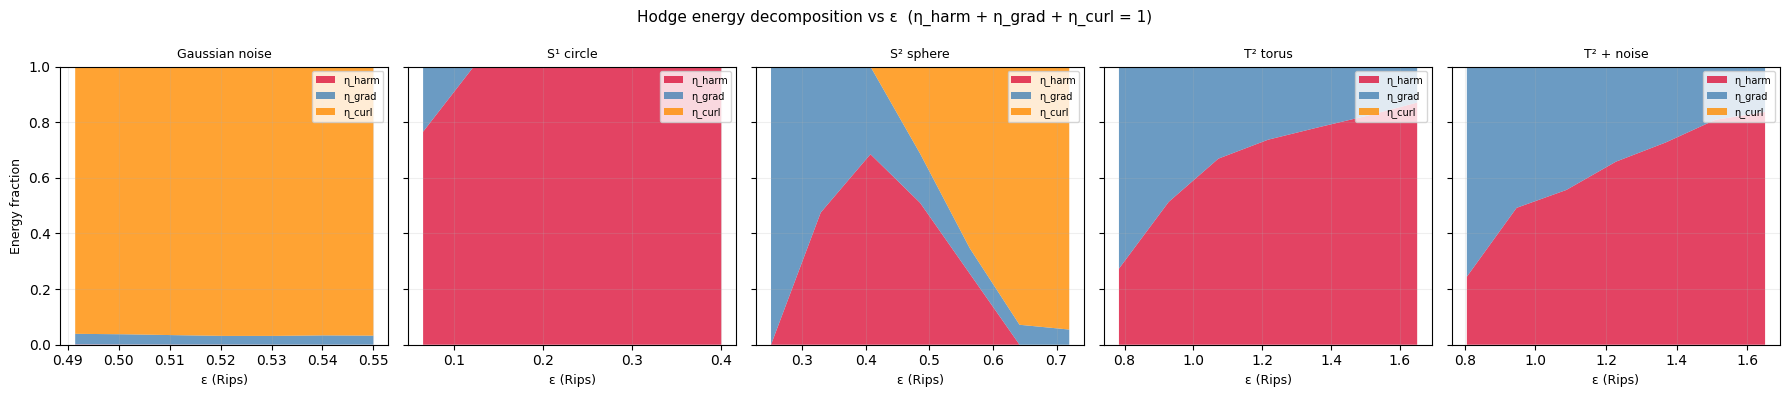

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

for ax, (name, records) in zip(axes, SWEEP.items()):
    if not records:
        ax.set_visible(False); continue
    eps  = np.array([r["epsilon"]  for r in records])
    harm = np.array([r["eta_harm"] for r in records])
    grad = np.array([r["eta_grad"] for r in records])
    curl = np.array([r["eta_curl"] for r in records])

    ax.stackplot(eps, harm, grad, curl,
                 labels=["\u03b7_harm", "\u03b7_grad", "\u03b7_curl"],
                 colors=["crimson", "steelblue", "darkorange"], alpha=0.80)
    ax.set_xlabel("\u03b5 (Rips)", fontsize=9)
    ax.set_title(name, fontsize=9)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Energy fraction", fontsize=9)
plt.suptitle(
    "Hodge energy decomposition vs \u03b5  (\u03b7_harm + \u03b7_grad + \u03b7_curl = 1)",
    fontsize=11,
)
plt.tight_layout()
plt.show()

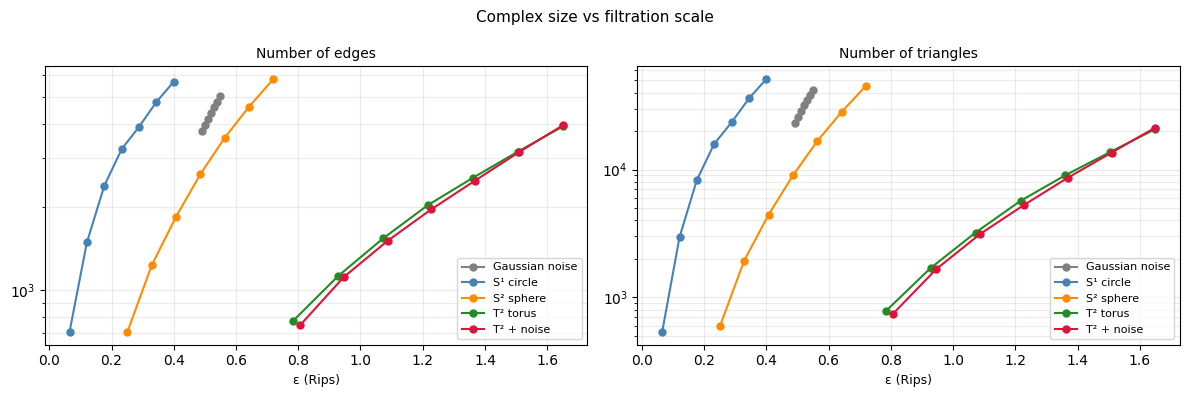

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, records in SWEEP.items():
    if not records: continue
    eps = [r["epsilon"]     for r in records]
    ne  = [r["n_edges"]     for r in records]
    nt  = [r["n_triangles"] for r in records]
    c   = SHAPE_COLORS[name]
    axes[0].semilogy(eps, ne, "o-", color=c, lw=1.5, label=name, ms=5)
    axes[1].semilogy(eps, nt, "o-", color=c, lw=1.5, label=name, ms=5)

for ax, title in zip(axes, ["Number of edges", "Number of triangles"]):
    ax.set_xlabel("\u03b5 (Rips)", fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25, which="both")

plt.suptitle("Complex size vs filtration scale", fontsize=11)
plt.tight_layout()
plt.show()

## §5  Summary

### What the ε sweep reveals

**Gaussian noise** — η_harm ≈ 0 and η_curl ≈ 0.96 throughout; β₁ fluctuates 4–9.
The high curl energy comes from angle-cochain wrapping across random triangles
(no consistent winding direction).  No stable spectral gap.

**S¹ circle** — η_harm rises from 0.77 at ε ≈ 0.06 to **1.00** at ε ≈ 0.29 and stays
there; β₁ = 1 (stable) with spectral gap ≈ 1.0.  η_curl = 0 because neighbouring
circle points always share small, non-wrapping angle differences — the angle cochain
is a near-cocycle.  The entire winding number lives in the harmonic subspace.

**S² sphere** — three distinct regimes:

| ε range | β₁ | η_harm | Interpretation |
|---|---|---|---|
| ε ≲ 0.33 | 20 (cap) | 0.00 | Sparse Rips; complex fragmented |
| 0.33–0.56 | 8–20 | 0.47–0.69 | Spurious H₁ loops not yet killed |
| ε ≳ 0.64 | 0 | 0.00 | Fully triangulated; η_curl → 0.93 |

The intermediate peak in η_harm is a **Vietoris–Rips artefact**: at these scales the
complex has many 1-cycles that the persistent-homology filtration would eventually
kill (they have short lifetimes), but within a fixed-ε complex they contribute to
the harmonic space.  At ε ≥ 0.64 all loops are filled and the sphere shows β₁ = 0
as expected.

**T² torus** — η_harm rises monotonically from 0.27 to **0.87**; β₁ decreases
20 → 7 as ε grows.  η_curl ≈ 0 throughout (the toroidal angle cochain wraps cleanly,
no cross-wrapping across triangles).  β₁ does not reach the topological value of 2
within the tested ε range: the VR complex needs a larger ε to kill the short-lived
spurious loops, but the ε cap (1.65) is set to limit computation time.  The rising
η_harm and eventually large spectral gap (11.3 at ε = 1.65) correctly signal the
presence of multiple harmonic modes.

**T² + noise** — same qualitative behaviour as T²; η_harm slightly lower (0.84 at
ε = 1.65), β₁ decreases faster (reaches 3 at ε = 1.65) because noise partially
fills gaps.


In [13]:
print("{:15s}  {:>8s}  {:>8s}  {:>8s}  {:>8s}  {:>4s}  {:>8s}  {:>8s}  {:>10s}".format(
    'Shape', 'ε_mid', 'η_harm', 'η_grad', 'η_curl', 'β₁', 'gap', 'edges', 'triangles'))
print("─" * 88)
for name, records in SWEEP.items():
    if not records: continue
    mid = records[len(records) // 2]
    print(f"{name:15s}  {mid['epsilon']:>8.4f}  {mid['eta_harm']:>8.4f}  "
          f"{mid['eta_grad']:>8.4f}  {mid['eta_curl']:>8.4f}  "
          f"{mid['beta1_hodge']:>4d}  {mid['spectral_gap']:>8.3f}  "
          f"{mid['n_edges']:>8d}  {mid['n_triangles']:>10d}")

Shape               ε_mid    η_harm    η_grad    η_curl    β₁       gap     edges   triangles
────────────────────────────────────────────────────────────────────────────────────────
Gaussian noise     0.5207    0.0006    0.0311    0.9683     6     1.467      4381       31700
S¹ circle          0.2325    0.9965    0.0035    0.0000     1     1.015      3239       15890
S² sphere          0.4853    0.5099    0.1768    0.3133     8     1.456      2627        8987
T² torus           1.2168    0.7370    0.2630    0.0000    20     0.000      2031        5689
T² + noise         1.2279    0.6581    0.3419    0.0000    20     0.000      1961        5284


### Takeaways for the rest of the series

| Feature | Noise | S¹ | S² | T² | T²+noise |
|---|---|---|---|---|---|
| β₁ (Hodge, max ε) | ~5 | **1** | 0 | ~7 | ~3 |
| η_harm (max ε) | ~0.00 | **1.00** | 0.00 | 0.87 | 0.84 |
| η_curl (max ε) | ~0.97 | 0.00 | ~0.95 | 0.00 | 0.00 |
| Spectral gap (max ε) | ~1.4 | 1.0 | ~2.0 | 11.3 | 1.1 |

**Key diagnostic signatures:**
- Large, stable η_harm with β₁ = 1 and gap ≈ 1 → clean circle topology (S¹, slug)
- η_curl ≈ 0 + rising η_harm → cochain is a near-cocycle with winding (torus/circle family)
- η_curl ≈ 1 + η_harm ≈ 0 → random or fully-triangulated geometry (noise, filled sphere)
- β₁ > 1 with gap ≈ 0 → transitional regime (Rips complex not yet stable)

In Notebooks 1–4 the slug limit cycle manifests as a circle (β₁ = 1) in the Takens
embedding.  Slugging wells show **η_harm → 1, β₁ = 1, gap ≈ 1** while noise or
steady-state flow show **η_harm ≈ 0, η_curl ≈ 1**.
